# Logistic Regression via Autograd 

In [16]:
from sklearn.datasets import load_breast_cancer
import torch

In [17]:
device  = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [18]:
torch.manual_seed(0)

X, y = load_breast_cancer(as_frame=True, return_X_y=True)
X = torch.tensor(X.values, dtype=torch.float32, device=device)
y = torch.tensor(y.values, dtype=torch.float32, device=device)

# Standardisation (par feature)
X = (X - X.mean(dim=0)) / X.std(dim=0)

num_feats = X.shape[1]

w = torch.randn(num_feats, requires_grad = True, device=device)
b = torch.randn(1, requires_grad = True, device=device)

# Modèle de logistic regression
def  sigmoid(x):
    return 1 / (1 + torch.exp(-x))

def compute_z(X, w, b):
    return sigmoid(torch.matmul(X, w) + b)

# Optimiseur et loss
learning_rate = 1e-1
optimizer = torch.optim.SGD([w, b], lr=learning_rate)
criterion = torch.nn.BCELoss()

# Entraînement
n_epochs = 500
for epoch in range(1, n_epochs+1):
    # Forward pass
    z = compute_z(X, w, b).clamp(min=0, max=1)

    # Affichage métrique
    accuracy = 100 * (((z > 0.5).float() == y).float()).mean().item()
    print(f'{accuracy=:.1f} %')

    # Calcul de la loss (erreur entre prédiction et vérité terrain)
    loss = criterion(z, y)

    # C'est ici que la magie opère -> Calcul du gradient automatique
    loss.backward()

    # Màj de w, b par descente de gradient
    optimizer.step()

    # Remise à zéro des gradients accumulés avant la prochaine itération (sinon ils s'accumulent)
    optimizer.zero_grad()


accuracy=78.0 %
accuracy=84.9 %
accuracy=85.4 %
accuracy=86.1 %
accuracy=87.0 %
accuracy=87.5 %
accuracy=87.9 %
accuracy=88.8 %
accuracy=89.8 %
accuracy=90.2 %
accuracy=90.5 %
accuracy=91.0 %
accuracy=91.4 %
accuracy=91.4 %
accuracy=91.4 %
accuracy=91.6 %
accuracy=91.6 %
accuracy=91.7 %
accuracy=91.7 %
accuracy=91.9 %
accuracy=92.1 %
accuracy=92.1 %
accuracy=92.3 %
accuracy=92.3 %
accuracy=92.4 %
accuracy=92.8 %
accuracy=93.3 %
accuracy=93.5 %
accuracy=93.7 %
accuracy=93.7 %
accuracy=93.7 %
accuracy=93.7 %
accuracy=93.7 %
accuracy=93.5 %
accuracy=93.8 %
accuracy=94.0 %
accuracy=94.0 %
accuracy=94.2 %
accuracy=94.4 %
accuracy=94.4 %
accuracy=94.4 %
accuracy=94.4 %
accuracy=94.4 %
accuracy=94.4 %
accuracy=94.6 %
accuracy=94.9 %
accuracy=94.9 %
accuracy=94.9 %
accuracy=94.9 %
accuracy=94.9 %
accuracy=94.9 %
accuracy=94.9 %
accuracy=94.7 %
accuracy=94.9 %
accuracy=94.9 %
accuracy=94.9 %
accuracy=94.9 %
accuracy=94.9 %
accuracy=94.9 %
accuracy=95.1 %
accuracy=94.9 %
accuracy=95.1 %
accuracy

# Multi-Layer Perceptron

### Création de la classe MLP

In [19]:
import torch
from torch import nn


class MLP(torch.nn.Module):
    def __init__(self, in_shape, n_neurons, num_hiddens_layers, num_classes):
        super(MLP, self).__init__()
        self.input_layer = nn.Linear(in_shape, n_neurons)
        layers = []
        for _ in range(num_hiddens_layers):
            layers.append(nn.Linear(n_neurons, n_neurons))
            layers.append(nn.ReLU())
        self.hidden_layers = nn.Sequential(*layers)
        self.output_layer = nn.Linear(n_neurons, num_classes, bias=False)

    def forward(self, x):
        i = nn.ReLU()(self.input_layer(x))
        h = self.hidden_layers(i)
        y = nn.Softmax(dim=1)(self.output_layer(h))

        return y


In [20]:
from sklearn.datasets import fetch_openml
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)

y = y.astype("int64") 

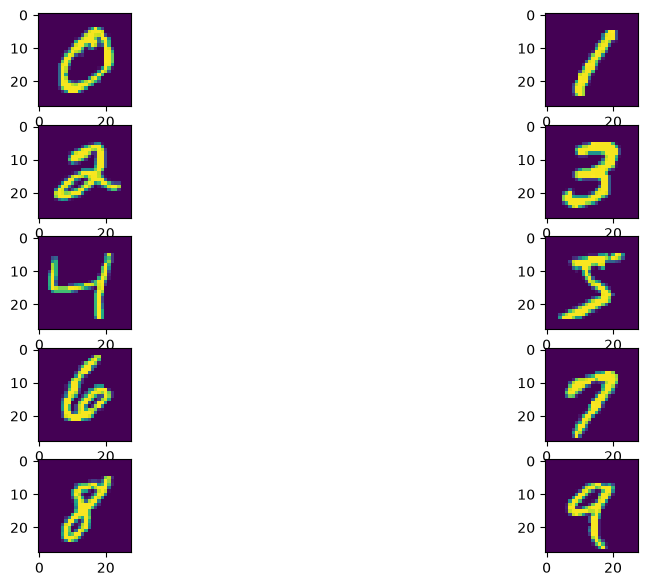

In [21]:
import matplotlib.pyplot as plt
import numpy as np

fig, axs = plt.subplots(5, 2)

fig.set_size_inches(12,7)
axs = axs.ravel()

for i in range(10):
    axs[i].imshow(X[np.argmax(y==i), :].reshape(28, 28))

In [22]:
mnist_classifier = MLP(in_shape=X.shape[1], 
                       n_neurons=256, num_hiddens_layers=3, num_classes=10)

In [23]:
sum(p.numel() for p in mnist_classifier.parameters())

400896

In [24]:
from torch.utils.data import Dataset, DataLoader

class MNISTDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32) / 255. # + torch.randn(X.shape)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        # Retourne une paire (image, label)
        return self.X[idx], self.y[idx]

In [25]:
m = X.shape[0]

idx_shuffle =torch.randperm(m)

X_train = X[idx_shuffle[:50000]]
X_val = X[idx_shuffle[50000:]]
y_train = y[idx_shuffle[:50000]]
y_val = y[idx_shuffle[50000:]]

In [26]:
# Optimiseur et loss
learning_rate = 1e-3
optimizer = torch.optim.Adam(mnist_classifier.parameters(), lr=learning_rate)
criterion = torch.nn.CrossEntropyLoss()

batch_size = 32
train_dataset = MNISTDataset(X_train, y_train)
val_dataset = MNISTDataset(X_val, y_val)

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# Entraînement
mnist_classifier = mnist_classifier.to(device)
n_epochs = 5
first = True
for epoch in range(1, n_epochs+1):
    total_train_loss = 0
    total_val_loss = 0
    correct_train = 0
    correct_val = 0
    total_train = 0
    total_val = 0
    
    # --- Apprentissage ---
    mnist_classifier.train()
    for xb, yb in train_dataloader:
        xb = xb.to(device)
        yb = yb.to(device)
        # Forward pass
        y_pred = mnist_classifier(xb)

        # Loss
        loss = criterion(y_pred, yb)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if first:
            print(mnist_classifier.hidden_layers[0].weight.grad)  # Affichage du gradient
            first = False
        
        # Accumulation des pertes
        total_train_loss += loss.item() * xb.size(0)

        # Accuracy
        preds = torch.argmax(y_pred, dim=1)
        correct_train += (preds == yb).sum().item()
        total_train += yb.size(0)

    epoch_loss_train = total_train_loss / total_train
    epoch_acc_train = 100 * correct_train / total_train

    # --- Validation ---
    mnist_classifier.eval()
    with torch.no_grad():
        for xb, yb in val_dataloader:
            xb = xb.to(device)
            yb = yb.to(device)
            y_pred = mnist_classifier(xb)
            loss = criterion(y_pred, yb)

            total_val_loss += loss.item() * xb.size(0)

            preds = torch.argmax(y_pred, dim=1)
            correct_val += (preds == yb).sum().item()
            total_val += yb.size(0)

    epoch_loss_val = total_val_loss / total_val
    epoch_acc_val = 100 * correct_val / total_val

    print(f"Epoch {epoch:3d} | "
          f"Train Loss: {epoch_loss_train:.4f} | Train Acc: {epoch_acc_train:.2f}% | "
          f"Val Loss: {epoch_loss_val:.4f} | Val Acc: {epoch_acc_val:.2f}%")


tensor([[-1.8995e-05, -2.8268e-05, -1.2357e-05,  ..., -1.8118e-05,
         -9.4352e-06, -8.6033e-07],
        [ 1.3049e-06,  1.3470e-06,  1.9499e-06,  ...,  4.8254e-07,
          8.6393e-07,  0.0000e+00],
        [ 0.0000e+00,  5.7930e-06,  3.7088e-06,  ...,  0.0000e+00,
          4.4320e-06,  0.0000e+00],
        ...,
        [-1.1529e-06, -3.1625e-06,  0.0000e+00,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [-2.2124e-06, -1.5419e-05, -1.5148e-05,  ..., -2.6860e-06,
          1.0036e-06, -3.8485e-07],
        [-2.4429e-06,  2.2232e-06,  1.1166e-06,  ...,  2.4240e-06,
         -6.0918e-06, -5.4065e-07]], device='cuda:0')
Epoch   1 | Train Loss: 1.6121 | Train Acc: 85.17% | Val Loss: 1.5723 | Val Acc: 88.97%
Epoch   2 | Train Loss: 1.5438 | Train Acc: 91.70% | Val Loss: 1.5558 | Val Acc: 90.49%
Epoch   3 | Train Loss: 1.5430 | Train Acc: 91.81% | Val Loss: 1.5600 | Val Acc: 90.11%
Epoch   4 | Train Loss: 1.5465 | Train Acc: 91.44% | Val Loss: 1.5463 | Val Acc: 91.48%

Text(0.5, 1.0, 'Prediction=1')

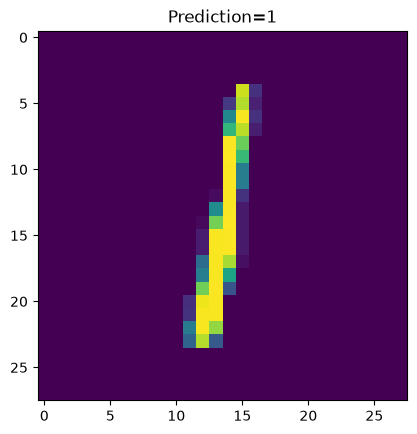

In [27]:
idx = np.random.randint(m)
pred_class = torch.argmax(mnist_classifier(torch.tensor(X[idx]).view(1, -1).to(device).to(torch.float) / 255.)).item()
plt.imshow(X[idx].reshape(28, 28))
plt.title(f'Prediction={pred_class}')

In [28]:
sum(p.numel() for p in mnist_classifier.parameters())

400896

# Exercice 
Réécrire la première cellule avec la logique PyTorch.

Cela nécessite de :
* Créer un dataset et un dataloader
* Créer un modèle LogisticRegression en héritant de torch.nn.Module

In [29]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.datasets import load_breast_cancer

# --- 0. Configuration du device ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(0)

# --- 1. Charger et préparer les données (Sur CPU par défaut) ---
X_raw, y_raw = load_breast_cancer(as_frame=True, return_X_y=True)
X_tensor = torch.tensor(X_raw.values, dtype=torch.float32)
y_tensor = torch.tensor(y_raw.values, dtype=torch.float32).unsqueeze(1)  # (N, 1) pour BCELoss

# Standardisation (sur CPU)
X_tensor = (X_tensor - X_tensor.mean(dim=0)) / X_tensor.std(dim=0)


# --- 2. Créer un Dataset personnalisé ---
class BreastCancerDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

full_dataset = BreastCancerDataset(X_tensor, y_tensor)

# --- CORRECTION: Split Train / Val (80% / 20%) ---
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=False)


# --- 3. Définition du Modèle ---
class MLP(torch.nn.Module):
    def __init__(self, in_shape, n_neurons, num_hiddens_layers):
        super(MLP, self).__init__()
        self.input_layer = nn.Linear(in_shape, n_neurons)
        
        layers = []
        for _ in range(num_hiddens_layers):
            layers.append(nn.Linear(n_neurons, n_neurons))
            layers.append(nn.ReLU())
        self.hidden_layers = nn.Sequential(*layers)
        
        self.output_layer = nn.Linear(n_neurons, 1, bias=False)

    def forward(self, x):
        i = nn.ReLU()(self.input_layer(x))
        h = self.hidden_layers(i)
        y = nn.Sigmoid()(self.output_layer(h)) # Sigmoid assure déjà l'intervalle [0, 1]
        return y

# Instanciation et envoi sur le device
model = MLP(X_tensor.shape[1], 32, 3).to(device)


# --- 4. Définir loss et optimiseur ---
criterion = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)


# --- 5. Entraînement ---
n_epochs = 100 # Redescendu à 100, le modèle converge très vite
for epoch in range(1, n_epochs + 1):
    model.train() # Mode entraînement activé
    
    for batch_X, batch_y in train_dataloader:
        # Envoi des mini-batchs sur le GPU/CPU au fil de l'eau
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        # Forward pass
        outputs = model(batch_X)

        # Calcul de la loss
        loss = criterion(outputs, batch_y)

        # Backprop (L'ordre standard et propre : zero_grad -> backward -> step)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # --- Évaluation sur l'ensemble de Validation ---
    model.eval() # Mode évaluation activé (désactive dropout/batchnorm si présents)
    with torch.no_grad():
        val_preds_list = []
        val_y_list = []
        for batch_X, batch_y in val_dataloader:
            batch_X = batch_X.to(device)
            preds = model(batch_X)
            
            val_preds_list.append(preds.cpu())
            val_y_list.append(batch_y)
            
        # Reconstitution des tenseurs globaux pour le calcul de la métrique
        all_val_preds = torch.cat(val_preds_list, dim=0)
        all_val_y = torch.cat(val_y_list, dim=0)
        
        accuracy = 100 * ((all_val_preds > 0.5) == all_val_y).float().mean().item()
        
    if epoch % 10 == 0 or epoch == 1:
        print(f'{epoch=}, Val {accuracy=:.1f} %')

epoch=1, Val accuracy=61.4 %
epoch=10, Val accuracy=96.5 %
epoch=20, Val accuracy=95.6 %
epoch=30, Val accuracy=97.4 %
epoch=40, Val accuracy=98.2 %
epoch=50, Val accuracy=98.2 %
epoch=60, Val accuracy=98.2 %
epoch=70, Val accuracy=98.2 %
epoch=80, Val accuracy=98.2 %
epoch=90, Val accuracy=98.2 %
epoch=100, Val accuracy=98.2 %


## MLP sur california housing dataset

In [30]:
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import torch.nn as nn

# --- 0. Configuration ---
torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 1. Chargement et Nettoyage des Données ---
data_path = "../datasets/housing/housing.csv"
data = pd.read_csv(data_path)
data = data.loc[data['housing_median_age'] < 52]
data = data.loc[data['median_house_value'] < 499999]
data = data.dropna()

x_numeric_columns = ['longitude', 'latitude', 'housing_median_age', 'total_rooms',
                     'total_bedrooms', 'population', 'households', 'median_income']

# Conversion explicite des booléens de get_dummies en float pour éviter les conflits
x_ocean_proximity_one_hot = pd.get_dummies(data["ocean_proximity"]).astype(float)

# Création directe de X et y en float32 (Type standard de PyTorch)
X = torch.hstack([
    torch.tensor(data[x_numeric_columns].values, dtype=torch.float32), 
    torch.tensor(x_ocean_proximity_one_hot.values, dtype=torch.float32)
])

# Standardisation
X = (X - X.mean(dim=0)) / X.std(dim=0)

# y est directement mis au format (N, 1) en float32
y = torch.tensor(data['median_house_value'].values, dtype=torch.float32).unsqueeze(1) / 1e5  # $ -> 100k$


# --- 2. Créer un Dataset personnalisé ---
class HousingDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
        
    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

full_dataset = HousingDataset(X, y)

# Split Train / Val (80% / 20%) pour une évaluation saine
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=False)


# --- 3. Définition du Modèle (MLP) ---
class MLP(torch.nn.Module):
    def __init__(self, in_shape, n_neurons, num_hiddens_layers):
        super(MLP, self).__init__()
        self.input_layer = nn.Linear(in_shape, n_neurons)
        layers = []
        for _ in range(num_hiddens_layers):
            layers.append(nn.Linear(n_neurons, n_neurons))
            layers.append(nn.ReLU())
        self.hidden_layers = nn.Sequential(*layers)
        self.output_layer = nn.Linear(n_neurons, 1, bias=False)

    def forward(self, x):
        i = nn.ReLU()(self.input_layer(x))
        h = self.hidden_layers(i)
        y = self.output_layer(h) # Pas d'activation finale pour de la régression linéaire/continue
        return y

model = MLP(X.shape[1], 64, 4).to(device)


# --- 4. Définir loss et optimiseur ---
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)


# --- 5. Entraînement ---
n_epochs = 30
for epoch in range(1, n_epochs + 1):
    model.train()
    for batch_X, batch_y in train_dataloader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)
        
        # Forward pass
        outputs = model(batch_X)

        # Calcul de la loss (batch_y est déjà en (N, 1) grâce au unsqueeze du début)
        loss = criterion(outputs, batch_y)

        # Backprop
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # --- Évaluation de la RMSE sur la Validation (Toutes les 10 époques) ---
    if epoch % 10 == 0 or epoch == 1:
        model.eval()
        with torch.no_grad():
            val_preds_list = []
            val_y_list = []
            for batch_X, batch_y in val_dataloader:
                batch_X = batch_X.to(device)
                preds = model(batch_X)
                
                val_preds_list.append(preds.cpu())
                val_y_list.append(batch_y) # batch_y est déjà sur CPU à l'origine dans le dataloader
            
            all_preds = torch.cat(val_preds_list, dim=0)
            all_y = torch.cat(val_y_list, dim=0)
            
            # RMSE
            rmse = torch.sqrt(((all_preds - all_y) ** 2).mean()).item()
            
        # L'unité étant en 100k$, une rmse de 0.5 signifie une erreur moyenne de 50 000$
        print(f'{epoch=}, Val RMSE = {rmse:.3f} (soit {rmse * 100:.1f}k$)')

epoch=1, Val RMSE = 0.609 (soit 60.9k$)
epoch=10, Val RMSE = 0.603 (soit 60.3k$)
epoch=20, Val RMSE = 0.525 (soit 52.5k$)
epoch=30, Val RMSE = 0.505 (soit 50.5k$)


## 🎁 BONUS (optionnel) — contenu de réserve

### Exercice bonus — Régulariser le MLP (Dropout) + *LR scheduler*
Reprenez votre classe `MLP` et l'entraînement sur California Housing / MNIST, puis :
1. ajoutez une couche `nn.Dropout(p=0.2)` entre deux couches cachées ;
2. ajoutez un planificateur de learning rate `CosineAnnealingLR` ;
3. comparez les courbes train/val avec et sans ces ajouts.

_Squelette de solution ci-dessous (nécessite PyTorch + les cellules précédentes exécutées)._


In [31]:
# import torch, torch.nn as nn
# class MLPReg(nn.Module):
#     def __init__(self, d_in, d_hidden=64, p_drop=0.2):
#         super().__init__()
#         self.net = nn.Sequential(
#             nn.Linear(d_in, d_hidden), nn.ReLU(),
#             nn.Dropout(p_drop),                 # <-- regularisation
#             nn.Linear(d_hidden, d_hidden), nn.ReLU(),
#             nn.Dropout(p_drop),
#             nn.Linear(d_hidden, 1))
#     def forward(self, x): return self.net(x)
#
# model = MLPReg(d_in=X_train.shape[1])
# opt = torch.optim.Adam(model.parameters(), lr=1e-3)
# scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
# for epoch in range(EPOCHS):
#     model.train()
#     ...  # forward / loss / backward / opt.step()
#     scheduler.step()                          # <-- on fait avancer le LR
#     # IMPORTANT : model.eval() avant l'evaluation pour desactiver le Dropout
print('Exercice bonus : voir le squelette ci-dessus. Comparez val_loss avec/sans Dropout.')


Exercice bonus : voir le squelette ci-dessus. Comparez val_loss avec/sans Dropout.
